# 🎓Polynomial Regression Explained Step-by-Step

This notebook provides a **student-friendly walkthrough** of how to use **Polynomial Regression** to model the relationship between a Titanic passenger's **age** and their **ticket fare**.

# **About the Author** 

Hello! I’m Asadullah Shehbaz — an aspiring Data Scientist on a journey of discovery and growth in the world of data.
I'm passionately exploring the realms of data science, diving deep into analytical techniques, machine learning, and real-world problem-solving to sharpen my skills and contribute meaningfully to this dynamic field.

> "I believe that community is the cornerstone of growth and innovation — by learning together, we can go further, faster, and stronger".

| Name               | Email                                               | LinkedIn                                                  | GitHub                                           | Kaggle                                        |
|--------------------|-----------------------------------------------------|-----------------------------------------------------------|--------------------------------------------------|-----------------------------------------------|
| **Asadullah Shehbaz**      |asadullahcreative@gmail.com  | [![LinkedIn Badge](https://img.shields.io/badge/LinkedIn-%23000000.svg?style=for-the-badge&logo=LinkedIn&logoColor=white)](https://www.linkedin.com/in/asadullah-shehbaz-18172a2bb/)  | [![GitHub Badge](https://img.shields.io/badge/GitHub-%23000000.svg?style=for-the-badge&logo=GitHub&logoColor=white)](https://github.com/AsadullahShehbaz)  | [![Kaggle Badge](https://img.shields.io/badge/Kaggle-%23000000.svg?style=for-the-badge&logo=Kaggle&logoColor=white)](https://www.kaggle.com/asadullahcreative)  |



---

# 🔍 **Objective**

> **Can we predict how much a passenger paid for their ticket based on their age?**  
We'll explore this using a **second-degree (quadratic) polynomial regression model**.

---

# 🧭 **What This Notebook Covers**

### 1. 📦 Load the Titanic Dataset
- Uses the Titanic dataset from `seaborn`.

---

### 2. 🧹 Data Preprocessing
- Selects only two columns:
  - `age` (independent variable)
  - `fare` (dependent variable)
- Removes rows where either value is missing (clean data = better model).

---

### 3. ✨ Polynomial Regression Pipeline
- Builds a machine learning pipeline:
  - `PolynomialFeatures(degree=2)` adds age² as a new feature.
  - `LinearRegression()` fits a curve instead of a straight line.
- Trains the model on 80% of the data and tests on the remaining 20%.

---

### 4. 📊 Model Evaluation
- Calculates and prints:
  - **MSE (Mean Squared Error)**: How far off are the predictions?
  - **R² Score**: How much variance in ticket price is explained by age?
- Provides a **plain-English interpretation** of what the numbers mean.

---

### 5. 📈 Visualisation
- Plots the actual data points (scatter plot).
- Overlays the fitted **polynomial curve**.
- Helps you **see** how well the model captures the trend.

---

## 💡 Key Learning Outcomes

- Understand how **polynomial regression** works under the hood.
- Learn how to preprocess real-world data and build a model using **scikit-learn pipelines**.
- Interpret **model metrics** like R² and MSE in a beginner-friendly way.
- Visualize regression fits in an intuitive, informative plot.

---

## 🛠️ Suggested Experiments

- 🔢 Try `degree=3` or `degree=4` for more flexible curves.
- ➕ Add more features like `pclass`, `sex`, or `embarked` to improve accuracy.
- 📉 Plot residuals to assess model bias.

---

> 📚 *A perfect beginner’s introduction to using regression models with real-world data!*


# **Practical Guide**  

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

---
### **1. Load the Titanic dataset**

In [9]:
import seaborn as sns
titanic = sns.load_dataset("titanic")
print("✓ Loaded Titanic dataset via seaborn.")


# Keep only rows where both Age and Fare are present
df = titanic[["age", "fare"]].dropna()

✓ Loaded Titanic dataset via seaborn.


---
### **2. Prepare the data**

In [10]:
X = df[["age"]]          # Predictor: passenger age
y = df["fare"]           # Target: ticket price (£)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

---
### **3. Polynomial Regression pipeline**

In [11]:
degree = 2
model = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('linearregression', LinearRegression())])

---
### **4. Predictions & Evaluation**

In [12]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("––––––– Model Performance –––––––")
print(f"Polynomial degree      : {degree}")
print(f"Test set MSE           : {mse:.2f}")
print(f"Test set R² (accuracy) : {r2:.2f}")


––––––– Model Performance –––––––
Polynomial degree      : 2
Test set MSE           : 4153.70
Test set R² (accuracy) : 0.00


Interpretation:
- An R² of 0.00 means roughly 0.2% of the variation in ticket price is explained by age using a quadratic curve.
- Lower MSE values indicate a better fit (here expressed in £²).
- If R² feels low, try adding more predictors (e.g., passenger class) or increasing the polynomial degree.

---
### 5. **Visualisation**

d:\Users\Asadullah Core\Apps\AS\envs\python_ml\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


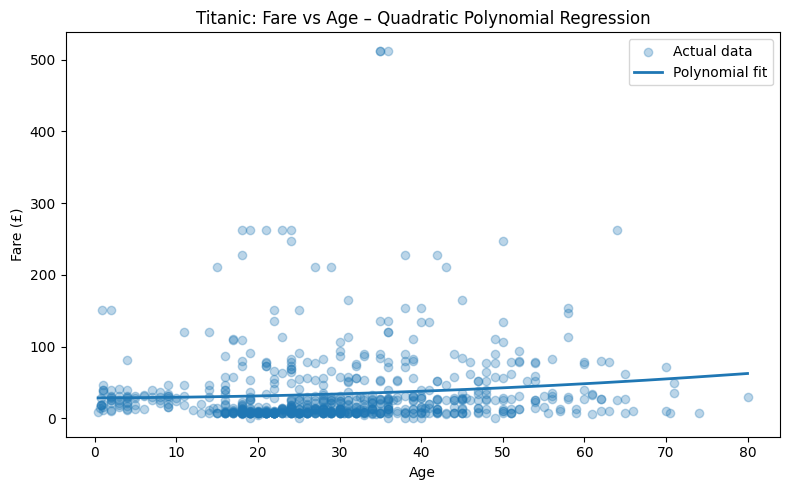

In [13]:
age_range = np.linspace(df["age"].min(), df["age"].max(), 300).reshape(-1, 1)
fare_pred = model.predict(age_range)

plt.figure(figsize=(8, 5))
plt.scatter(df["age"], df["fare"], alpha=0.3, label="Actual data")
plt.plot(age_range, fare_pred, linewidth=2, label="Polynomial fit")
plt.xlabel("Age")
plt.ylabel("Fare (£)")
plt.title("Titanic: Fare vs Age – Quadratic Polynomial Regression")
plt.legend()
plt.tight_layout()
plt.show()
